# Session 2 — Feature Engineering for Materials: Composition-Based Feature Vectors

**Practical AI & Machine Learning for Materials Science · ACerS short course**

In this notebook you will:
1. Build a composition-based feature vector (CBFV) **by hand** for Al₂O₃.
2. Featurize thousands of compounds automatically.
3. Compare different *representations* of the same data: one-hot, Magpie, Oliynyk, mat2vec and random numbers.
4. Add your own domain-knowledge features and discuss the limits of composition-only models.

> **Key idea:** the representation usually matters more than the choice of model.

**Optional pre-watch:** "Featurization" and "Composition-based feature vector" lectures on the
[course YouTube playlist](https://youtube.com/playlist?list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0).
Slides: [8. Featurization](https://github.com/sp8rks/MaterialsInformatics/blob/main/course_notes/8.%20Featurization.pdf),
[9. Composition based feature vector](https://github.com/sp8rks/MaterialsInformatics/blob/main/course_notes/9.%20Composition%20based%20feature%20vector.pdf).

## 0. Setup

In [1]:
# --- Setup: works locally and in Google Colab ---------------------------------
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/sp8rks/ACerS_AI_ML_Workshop"
if "google.colab" in sys.modules:
    ROOT = Path("/content/ACerS_AI_ML_Workshop")
    if not ROOT.exists():
        subprocess.run(["git", "clone", "-q", REPO_URL, str(ROOT)], check=True)
else:
    ROOT = Path.cwd().resolve()
    while not (ROOT / "workshop_utils").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("Workshop root:", ROOT)

Workshop root: C:\ACERS_AI_ML


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

from workshop_utils import (load_dataset, element_fractions, load_element_properties,
                            featurize_formula, generate_features, ELEMENT_TABLES)

plt.rcParams["figure.dpi"] = 110

## 1. Element property tables

A CBFV starts from a table of **elemental** properties. Each row is an element and each column is a property such as electronegativity, atomic radius or melting point.
The Oliynyk table was hand-curated by a solid-state chemist (Anton Oliynyk). Magpie comes from Ward *et al.* (2016). mat2vec embeddings were *learned* from 3 million paper abstracts.

In [3]:
olk = load_element_properties("oliynyk")
print(olk.shape)
olk.loc[["Al", "O", "Ti", "Zr"], olk.columns[:10]]

(85, 44)


,Atomic_Number,Atomic_Weight,Period,group,families,Metal,Nonmetal,Metalliod,Mendeleev_Number,l_quantum_number
element,,,,,,,,,,
Al,13.0,26.981539,3.0,13.0,5.0,1.0,0.0,0.0,73.0,1.0
O,8.0,15.999400,2.0,16.0,7.0,0.0,1.0,0.0,87.0,1.0
Ti,22.0,47.880000,4.0,4.0,4.0,1.0,0.0,0.0,43.0,2.0
Zr,40.0,91.224000,5.0,4.0,4.0,1.0,0.0,0.0,44.0,2.0


In [4]:
for name in ELEMENT_TABLES:
    print(f"{name:10s}: {load_element_properties(name).shape[1]:4d} properties per element")

oliynyk   :   44 properties per element
magpie    :   22 properties per element
mat2vec   :  200 properties per element
onehot    :  119 properties per element
random_200:  200 properties per element


## 2. A CBFV by hand: Al₂O₃

For every elemental property $p$ and element fractions $w_i$, we compute summary statistics:

| statistic | formula | intuition |
|---|---|---|
| `avg` | $\sum_i w_i p_i$ | the "average atom" |
| `dev` | $\sum_i w_i \lvert p_i - \bar p \rvert$ | how *different* the elements are |
| `range` | $\max p_i - \min p_i$ | contrast (e.g. electronegativity difference → ionicity) |
| `max`, `min` | | extremes |
| `mode` | $p$ of the majority element | the "host" element |

In [5]:
fracs = element_fractions("Al2O3")
prop = "Pauling_Electronegativity"
p = olk.loc[list(fracs), prop]
w = pd.Series(fracs)
avg = (w * p).sum()
print("fractions:", fracs)
print(f"{prop}: Al={p['Al']}, O={p['O']}")
print(f"avg   = {avg:.3f}")
print(f"dev   = {(w * (p - avg).abs()).sum():.3f}")
print(f"range = {p.max() - p.min():.3f}")

fractions: {'Al': 0.4, 'O': 0.6}
Pauling_Electronegativity: Al=1.61, O=3.44
avg   = 2.708
dev   = 0.878
range = 1.830


In [6]:
# Same thing via the helper, for all 44 Oliynyk properties x 6 statistics
v = featurize_formula("Al2O3", "oliynyk")
print(len(v), "features")
v[[f"{s}_{prop}" for s in ["avg", "dev", "range", "max", "min", "mode"]]]

264 features


avg_Pauling_Electronegativity      2.7080
dev_Pauling_Electronegativity      0.8784
range_Pauling_Electronegativity    1.8300
max_Pauling_Electronegativity      3.4400
min_Pauling_Electronegativity      1.6100
mode_Pauling_Electronegativity     3.4400
dtype: float64

✏️ **Quick check:** compute `avg_Pauling_Electronegativity` for MgAl₂O₄ by hand, then confirm it with `featurize_formula`.

In [7]:
featurize_formula("MgAl2O4")["avg_Pauling_Electronegativity"]

np.float64(2.6128571428571425)

## 3. Featurize a whole dataset
Raw compositions → feature matrix `X` and target vector `y`.

In [8]:
df = load_dataset("bulk_modulus")
X, y, formulae, skipped = generate_features(df, elem_prop="oliynyk")
X.head()

Featurized 4873 formulas into 264 'oliynyk' features (skipped 32)


,avg_Atomic_Number,avg_Atomic_Weight,avg_Period,avg_group,avg_families,avg_Metal,avg_Nonmetal,avg_Metalliod,avg_Mendeleev_Number,avg_l_quantum_number,...,mode_polarizability(A^3),mode_Melting_point_(K),mode_Boiling_Point_(K),mode_Density_(g/mL),mode_specific_heat_(J/g_K)_,mode_heat_of_fusion_(kJ/mol)_,mode_heat_of_vaporization_(kJ/mol)_,mode_thermal_conductivity_(W/(m_K))_,mode_heat_atomization(kJ/mol),mode_Cohesive_energy
0,52.00,122.770333,5.333333,7.000000,3.666667,1.000000,0.0,0.000000,49.666667,2.333333,...,8.6,2239.15,4000.15,12.40,0.242,21.500,493.0,150.0,556.0,5.75
1,67.00,166.203500,6.000000,6.000000,3.000000,1.000000,0.0,0.000000,36.000000,1.000000,...,39.7,998.15,1913.15,3.50,0.204,7.750,142.0,18.4,180.0,1.90
2,34.50,80.626223,4.166667,8.833333,4.500000,0.666667,0.0,0.333333,56.833333,1.833333,...,9.6,2583.15,4173.15,12.40,0.238,24.000,595.0,117.0,643.0,6.74
3,74.75,186.694995,6.000000,9.500000,4.000000,1.000000,0.0,0.000000,56.750000,2.000000,...,6.1,1337.15,3353.15,19.30,0.128,12.550,334.4,317.0,366.0,3.81
4,40.90,94.959840,4.650000,11.200000,4.350000,1.000000,0.0,0.000000,64.650000,1.050000,...,7.7,505.15,2543.15,7.31,0.227,7.029,295.8,66.6,302.0,3.14


## 4. Does the representation matter?

Same data, same model (random forest), same 5-fold cross-validation. The only thing we change is the **features**.

- `onehot`: element fractions only, with no chemical knowledge
- `random_200`: 200 random numbers per element (a sanity-check baseline!)
- `magpie`, `oliynyk`: physics- and chemistry-informed properties
- `mat2vec`: word embeddings learned from the literature

In [9]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)
results = {}
for elem_prop in ["onehot", "random_200", "magpie", "oliynyk", "mat2vec"]:
    Xr, yr, _, _ = generate_features(df, elem_prop=elem_prop, verbose=False)
    # 'avg' alone keeps the comparison fast and fair across tables
    Xr = Xr.filter(like="avg_")
    model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=0)
    mae = -cross_val_score(model, Xr, yr, cv=cv, scoring="neg_mean_absolute_error")
    results[elem_prop] = mae
    print(f"{elem_prop:10s} {Xr.shape[1]:4d} features   MAE = {mae.mean():5.1f} ± {mae.std():.1f} GPa")

onehot      119 features   MAE =  17.6 ± 0.7 GPa


random_200  200 features   MAE =  21.9 ± 1.0 GPa


magpie       22 features   MAE =  14.1 ± 0.7 GPa


oliynyk      44 features   MAE =  12.7 ± 0.5 GPa


mat2vec     200 features   MAE =  15.9 ± 0.7 GPa


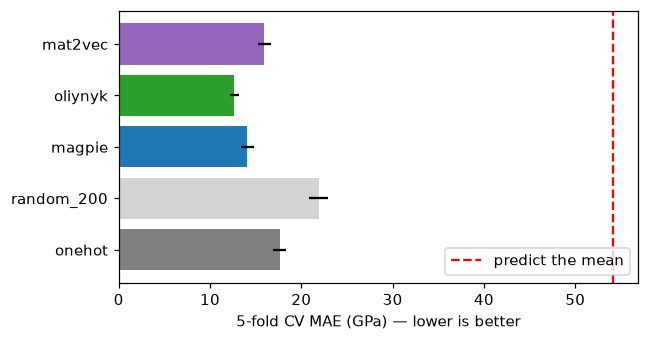

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.2))
names = list(results)
ax.barh(names, [results[n].mean() for n in names], xerr=[results[n].std() for n in names],
        color=["gray", "lightgray", "tab:blue", "tab:green", "tab:purple"])
ax.axvline(np.mean(np.abs(y - y.mean())), color="red", ls="--", label="predict the mean")
ax.set_xlabel("5-fold CV MAE (GPa) — lower is better")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Discussion questions**
- How much better than "predict the mean" are we?
- Random element vectors are *not* useless. Why? (Hint: with enough data a model can learn element identity from any unique code. Chemistry-aware features help most when data is **scarce**.)
- Try the comparison again with only 200 training compounds (exercise below). Does the ranking change?

## 5. Adding *domain knowledge*

You know things the element tables don't. Examples for ceramics:
- anion identity (oxide, nitride, carbide…)
- average valence-electron concentration
- ionic character from an electronegativity difference

Let's add a couple of handcrafted features and see whether they help.

In [11]:
from workshop_utils import parse_formula

def domain_features(formula):
    els = parse_formula(formula)
    fr = element_fractions(formula)
    return {
        "is_oxide": float("O" in els),
        "is_nitride": float("N" in els),
        "is_carbide": float("C" in els),
        "is_boride": float("B" in els),
        "n_elements": len(els),
        "anion_fraction": sum(fr.get(a, 0) for a in ["O", "N", "C", "B", "F", "S"]),
    }

D = pd.DataFrame([domain_features(f) for f in formulae])
X_olk = X.filter(like="avg_")
X_plus = pd.concat([X_olk, D], axis=1)

model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=0)
for name, Xd in [("oliynyk avg", X_olk), ("oliynyk avg + domain", X_plus)]:
    mae = -cross_val_score(model, Xd, y, cv=cv, scoring="neg_mean_absolute_error")
    print(f"{name:22s} MAE = {mae.mean():.1f} ± {mae.std():.1f} GPa")

oliynyk avg            MAE = 12.7 ± 0.5 GPa


oliynyk avg + domain   MAE = 12.6 ± 0.5 GPa


Small or no gains are normal when the element tables already encode similar information, and they are still informative. In small-data settings (tens of samples), domain features are often what makes a model work at all.

## 6. Limitations of composition-only models

A formula maps to **one** feature vector, but one formula can be many materials:

In [12]:
for f in ["C", "TiO2", "SiO2", "BN"]:
    print(f, "→ identical feature vector for every polymorph, e.g.",
          {"C": "diamond vs graphite", "TiO2": "rutile vs anatase vs brookite",
           "SiO2": "quartz vs cristobalite vs glass", "BN": "h-BN vs c-BN"}[f])

C → identical feature vector for every polymorph, e.g. diamond vs graphite
TiO2 → identical feature vector for every polymorph, e.g. rutile vs anatase vs brookite
SiO2 → identical feature vector for every polymorph, e.g. quartz vs cristobalite vs glass
BN → identical feature vector for every polymorph, e.g. h-BN vs c-BN


Composition-only features also ignore **processing** (sintering temperature, grain size, porosity, dopant segregation), which often dominates properties like strength, toughness and ionic conductivity.

**Ways forward:**
- structure-based features (Materials Project + `pymatgen`/`matminer`, crystal graph networks), see the full course's lectures 10–11
- add processing variables as extra columns, which we do for heat capacity vs. temperature in Session 4
- be explicit about what your model *can't* know

## 7. Hands-on exercises

1. **Small data:** repeat the representation comparison using only 200 randomly sampled compounds (`df.sample(200, random_state=1)`). Which representation wins now?
2. **All statistics:** use the full Oliynyk CBFV (avg + dev + range + max + min + mode) instead of `avg` only. Is it worth 6× the features?
3. **Your chemistry:** featurize 3–5 compositions from your own research with `featurize_formula`. Are any elements missing from the tables?
4. **Another property:** swap in `load_dataset("shear_modulus")` or `load_dataset("log10_thermal_conductivity")`.

In [13]:
# Exercise 1 starter
small = df.sample(200, random_state=1)
for elem_prop in ["onehot", "random_200", "oliynyk"]:
    Xs, ys, _, _ = generate_features(small, elem_prop=elem_prop, verbose=False)
    mae = -cross_val_score(RandomForestRegressor(n_estimators=100, random_state=0),
                           Xs.filter(like="avg_"), ys, cv=cv, scoring="neg_mean_absolute_error")
    print(f"{elem_prop:10s} MAE = {mae.mean():.1f} GPa")

onehot     MAE = 32.5 GPa


random_200 MAE = 38.1 GPa


oliynyk    MAE = 22.6 GPa


In [14]:
# Exercise 3 starter: your compositions here
my_formulas = ["Al2O3", "Y0.08Zr0.92O1.96", "Si3N4", "Ti3SiC2", "LiFePO4"]
pd.DataFrame([featurize_formula(f) for f in my_formulas], index=my_formulas).iloc[:, :6]

,avg_Atomic_Number,avg_Atomic_Weight,avg_Period,avg_group,avg_families,avg_Metal
Al2O3,10.000000,20.392256,2.400000,14.800000,6.200000,0.400000
Y0.08Zr0.92O1.96,18.783784,41.350464,3.013514,11.918919,5.959459,0.337838
Si3N4,10.000000,20.040494,2.428571,14.571429,6.571429,0.000000
Ti3SiC2,15.333333,32.624583,3.166667,9.000000,5.333333,0.500000
LiFePO4,10.857143,22.537052,2.428571,12.571429,5.714286,0.285714


---
**Next session:** supervised learning (regression and classification) and how *not* to fool yourself with validation.

**Go deeper:** [CBFV package](https://github.com/kaaiian/CBFV) · [matminer](https://hackingmaterials.lbl.gov/matminer/) ·
full course `worked_examples/CBFV_example` and `worked_examples/RDKit_tutorial` (molecules/polymers) ·
Murdock *et al.*, "Is domain knowledge necessary for machine learning materials properties?" [IMMI 2020](https://doi.org/10.1007/s40192-020-00179-z).